In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Load Dog Image and Plot it

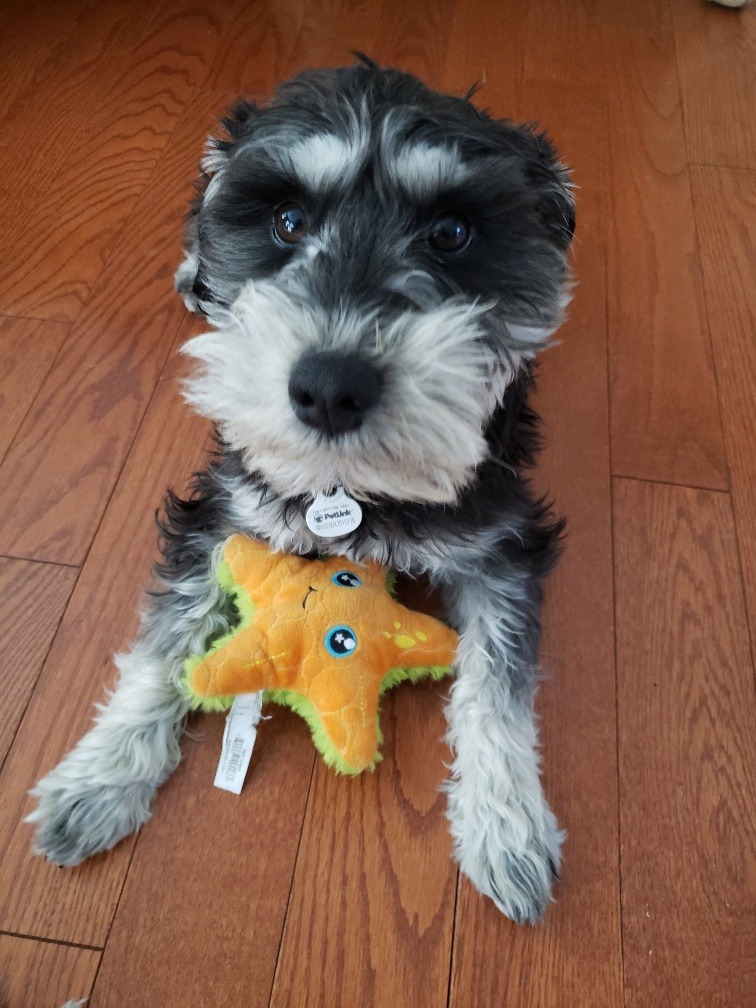

<Figure size 800x600 with 0 Axes>

In [ ]:
from matplotlib import image
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = cv2.imread(work_path + 'Data/Dog.jpg')

plt.figure(figsize=(8, 6))
cv2_imshow(img)

In [ ]:
# Convert to graycsale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sobel
sobeld = cv2.Sobel(src=img_gray, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
cv2_imshow(sobeld)
# Canny
cannyd = cv2.Canny(image=img_gray, threshold1=100, threshold2=200) # Combined X and Y Sobel Edge Detection
cv2_imshow(cannyd)
# Laplacian
kernel3 = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
laplaciand= cv2.filter2D(img_gray, -1, kernel3)
cv2_imshow(laplaciand)
# Laplacian of Gaussian
kernel5 = np.array([[0,0,-1,0,0],[0,-1,-2,-1,0],[-1,-2,16,-2,-1], [0,-1,-2,-1,0], [0,0,-1,0,0]])
logd = cv2.filter2D(img_gray, -1, kernel5)
cv2_imshow(logd)
# Prewitt
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
img_prewittx = cv2.filter2D(img_gray, -1, kernelx.T)
img_prewitty = cv2.filter2D(img_gray, -1, kernely.T)
img_prewittd = np.abs(img_prewittx) + np.abs(img_prewitty)
cv2_imshow(img_prewittd)
# Plot
# from left to right: Sobel, Canny, Laplacian, LoG, Prewitty
#numpy_horizontal_concat = np.concatenate((sobelxy, cannyxy, laplacian, log, img_prewittxy), axis=1)
#cv2_imshow(numpy_horizontal_concat)



Output hidden; open in https://colab.research.google.com to view.

# Airplane Image

Load airplane image

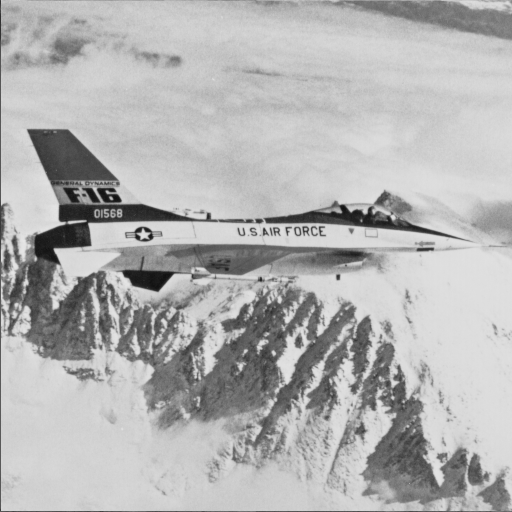

In [ ]:
from array import array
import os
import numpy as np
import cv2
from scipy import ndimage
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# load image
img = cv2.imread(work_path + 'Data/airplanes.png')

cv2_imshow(img)

Different Laplacian approaches:

For cv2, see: https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#gad78703e4c8fe703d479c1860d76429e6

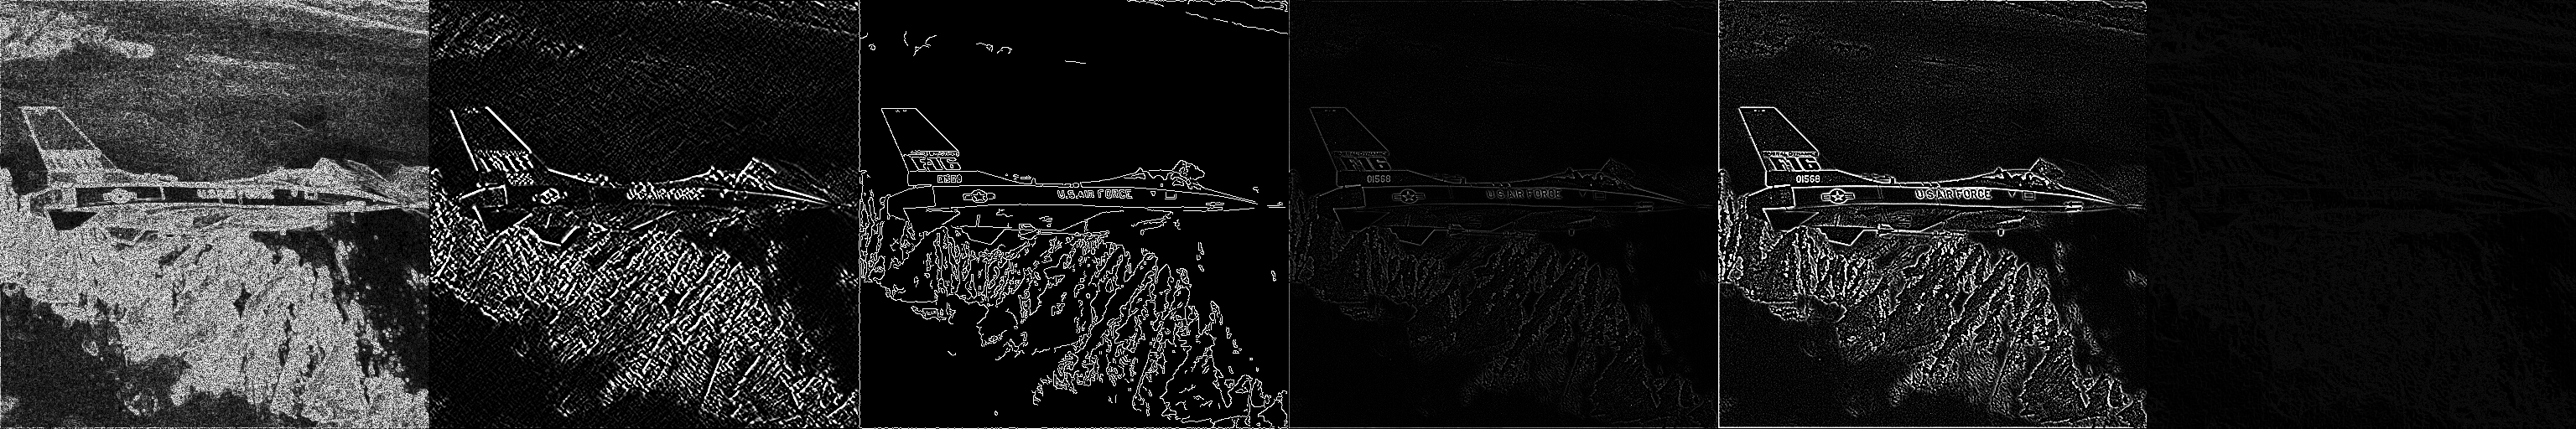

In [ ]:
from PIL import Image
import numpy as np

# Convert to graycsale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sobel
sobelxy = cv2.Sobel(src=img_gray, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection

# Canny
cannyxy = cv2.Canny(image=img_gray, threshold1=100, threshold2=200) # Combined X and Y Sobel Edge Detection

# Laplacian
kernel3 = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
laplacian= cv2.filter2D(img_gray, -1, kernel3)

#lap_1 = cv2.Laplacian(img_gray, cv2.CV_64F)
#laplacian = np.uint(np.absolute(lap_1))

#laplacian = ndimage.convolve(img_gray, kernel3)

# Laplacian of Gaussian
kernel5 = np.array([[0,0,-1,0,0],[0,-1,-2,-1,0],[-1,-2,16,-2,-1], [0,-1,-2,-1,0], [0,0,-1,0,0]])
log = cv2.filter2D(img_gray, -1, kernel5)

# Prewitt
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
img_prewittx = cv2.filter2D(img_gray, -1, kernelx.T)
img_prewitty = cv2.filter2D(img_gray, -1, kernely.T)
img_prewittxy = np.abs(img_prewittx) + np.abs(img_prewitty)

# Roberts
kernelrx = np.array([[1, 0], [0, -1]])
kernelry = np.array([[0, 1], [-1, 0]])
#kernelrx = np.array([[0,0,0],[0,1,0],[0,0,-1]])
#kernelry = np.array([[0,0,0],[0,0,1],[0,-1,0]])

# Convolve the image with the kernels
vertical = ndimage.convolve(img_gray, kernelrx)
horizontal = ndimage.convolve(img_gray, kernelry)

    # Calculate the magnitude of the gradient
img_rob = np.sqrt(np.square(horizontal) + np.square(vertical))

min_out=0
max_out=255
img_arr = np.array(img_rob)

min_in = np.min(img_arr)
max_in = np.max(img_arr)

stretched_array = (img_arr - min_in) * ((max_out - min_out) / (max_in - min_in)) +min_out
stretched_array = np.clip(stretched_array, min_out, max_out).astype(np.uint8)


# Plot
# from left to right: Roberts, Sobel, Canny, Laplacian, LoG, Prewitty
numpy_horizontal_concat = np.concatenate((stretched_array, sobelxy, cannyxy, laplacian, log, img_prewittxy), axis=1)
cv2_imshow(numpy_horizontal_concat)


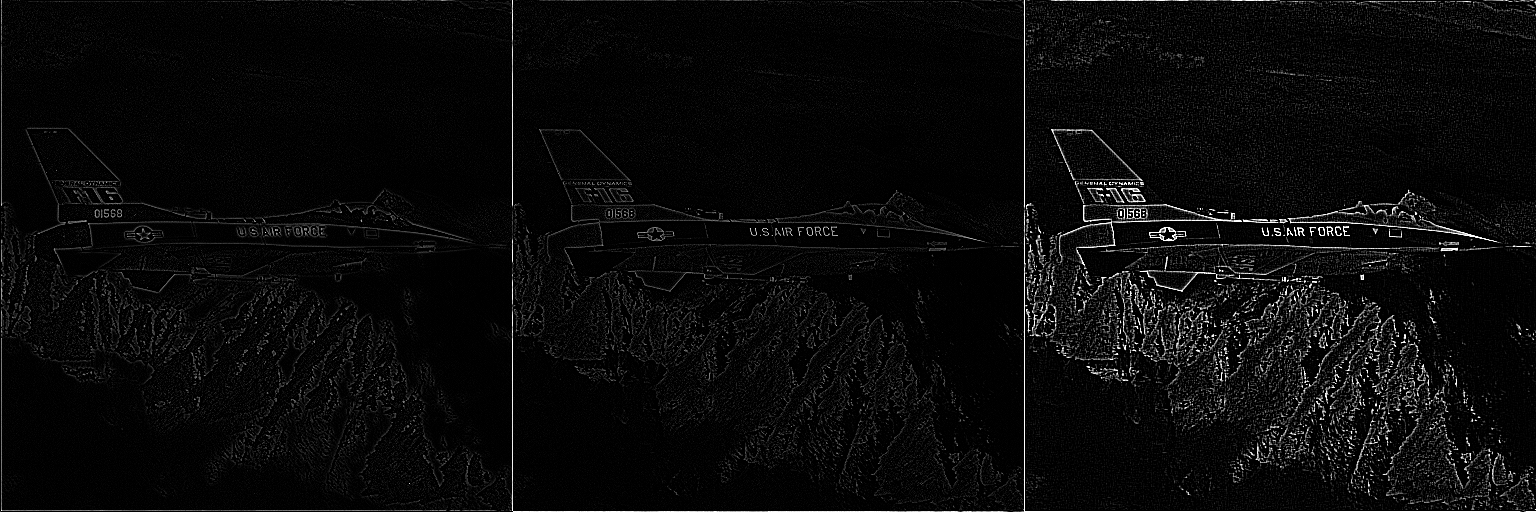

In [ ]:
# Laplacian
kernel3 = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
laplacian1= cv2.filter2D(img_gray, -1, kernel3)
# laplacian1= cv2.filter2D(laplacian1, -1, kernel3)

laplacian2 = cv2.Laplacian(img_gray, cv2.CV_64F, ksize=1)

laplacian3 = cv2.Laplacian(img_gray, cv2.CV_64F, ksize=3)

# Plot from left to right:
# My own defined kernel, cv2 package
numpy_horizontal_concat = np.concatenate((laplacian1, laplacian2, laplacian3), axis=1)
cv2_imshow(numpy_horizontal_concat)